# Ⅲ. 데이터와 기계학습
## 2. 기계학습 모델
### 3-2-1 분류 모델 (속성과 유형: KNN & 로지스틱 회귀)

---
* **학습 목표**
  1. 분류 모델의 개념을 이해하고, $k$-최근접 이웃($k$-NN)과 로지스틱 회귀의 작동 원리를 설명할 수 있다.
  2. 데이터의 속성과 유형에 따라 적절한 분류 모델을 선택할 수 있다.
  3. 구글 코랩(Google Colab) 환경에서 두 모델을 구현하고 시각화하여 성능을 대조할 수 있다.

* **핵심 요소**
  * 분류 모델(Classification Model)
  * $k$-최근접 이웃($k$-NN, $k$-Nearest Neighbors)
  * 로지스틱 회귀(Logistic Regression)
  * 결정 경계(Decision Boundary)

## 1. 분류 모델의 개요

### **(1) 분류 모델이란 무엇일까?**
* **정의**: 기계학습의 지도학습(Supervised Learning) 중 하나로, 입력된 데이터의 속성(Feature)들을 분석하여 미리 정의된 몇 개의 범주(Class/Label) 중 하나로 예측하여 출력하는 모델입니다.
* **출력값의 형태**: 연속적인 수치(예: 온도, 가격)를 예측하는 회귀 모델과 달리, 분류 모델은 '스팸/정상', '붓꽃의 품종(Setosa/Versicolor/Virginica)'과 같이 불연속적인 이산형 변수(범주형 데이터)를 출력합니다.

### **(2) 주요 분류 알고리즘**
1. **$k$-최근접 이웃 ($k$-NN)**: 데이터 간의 거리를 측정하여 가장 가까운 이웃들의 선택을 따르는 직관적인 알고리즘입니다.
2. **로지스틱 회귀 (Logistic Regression)**: 데이터가 특정 범주에 속할 확률을 0과 1 사이의 S자 곡선(시그모이드 함수)으로 계산하여 분류하는 알고리즘입니다.

## 2. $k$-최근접 이웃 ($k$-NN) 알고리즘의 원리

### **(1) 작동 메커니즘**
* "유리창을 통해 비치는 주변 풍경과 유사한 성질을 갖는다"는 유추에서 출발합니다.
* 새로운 데이터가 주어졌을 때, 기존 데이터 공간에서 가장 가까운 거리(대개 유클리드 거리)에 있는 $k$개의 데이터를 찾습니다.
* 찾은 이웃 데이터 중 가장 다수를 차지하는 범주(다수결의 원칙)로 새로운 데이터의 범주를 결정합니다.



### **(2) 하이퍼파라미터 $k$의 영향**
* **$k$가 너무 작을 때 ($k=1$)**: 모델이 매우 민감해져 학습 데이터의 노이즈나 이상치(Outlier)까지 학습하게 되며, **과대적합(Overfitting)**이 발생할 수 있습니다.
* **$k$가 너무 클 때**: 주변의 넓은 범위 데이터를 모두 포함하므로 분류 경계가 지나치게 뭉툭해져 세밀한 패턴을 놓치는 **과소적합(Underfitting)**이 발생할 수 있습니다.

## 3. 로지스틱 회귀 (Logistic Regression) 알고리즘의 원리

### **(1) 작동 메커니즘**
* 이름은 '회귀'이지만 선형 회귀 분석의 출력을 범주형 데이터를 처리할 수 있도록 확장한 **분류 알고리즘**입니다.
* 선형 회귀의 선형 결합 수식 $z = w_1x_1 + w_2x_2 + ... + b$의 결과값은 $-\infty$부터 $+\infty$까지의 범위를 가집니다. 이를 확률값으로 변환하기 위해 **시그모이드 함수(Sigmoid Function)**에 입력합니다.

### **(2) 시그모이드 함수 공식**
$$y = \frac{1}{1 + e^{-z}}$$

* 이 함수의 출력값 $y$는 항상 $0 \le y \le 1$의 범위를 가지며, 특정 클래스에 속할 **확률**을 나타냅니다.
* 기본적으로 출력 확률이 0.5(기준치) 이상이면 양성 클래스(1), 0.5 미만이면 음성 클래스(0)로 분류 기준을 수립합니다.

In [2]:
# [실습 1] 구글 코랩 환경 설정 및 한글 폰트 매핑
import sys
import os
import subprocess
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import pandas as pd
import numpy as np

def set_korean_font():
    is_colab = "google.colab" in sys.modules

    if is_colab:
        font_path = "/usr/share/fonts/truetype/nanum/NanumGothic.ttf"

        if not os.path.exists(font_path):
            subprocess.run(["apt-get", "update", "-qq"], check=False)
            subprocess.run(["apt-get", "install", "-y", "fonts-nanum"], check=False)
            subprocess.run(["fc-cache", "-fv"], check=False)

        fm.fontManager.addfont(font_path)
        plt.rcParams["font.family"] = "NanumGothic"

    elif sys.platform == "darwin":
        plt.rcParams["font.family"] = "AppleGothic"

    elif sys.platform.startswith("win"):
        plt.rcParams["font.family"] = "Malgun Gothic"

    else:
        plt.rcParams["font.family"] = "NanumGothic"

    plt.rcParams["axes.unicode_minus"] = False

set_korean_font()
print("구글 코랩 환경 한글 폰트 적용 완료.")

구글 코랩 환경 한글 폰트 적용 완료.


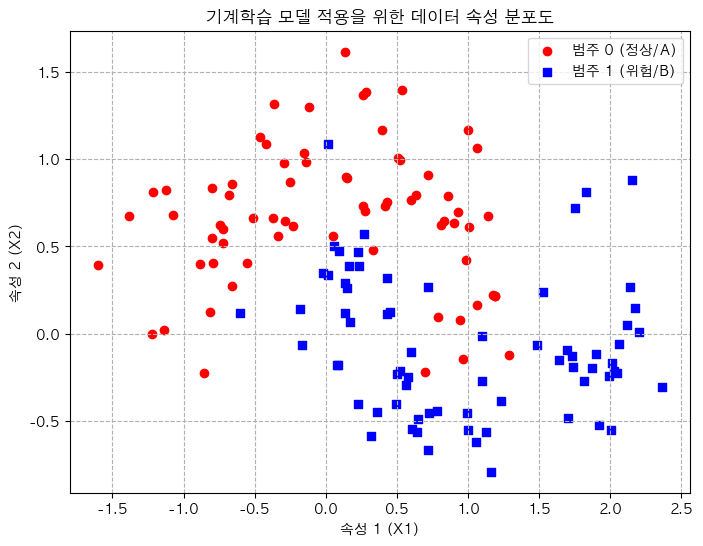

In [4]:
# [실습 2] KNN과 로지스틱 회귀 분석을 위한 가상 데이터 세트 생성
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split

# 두 개의 데이터 속성(Feature)을 가진 2차원 분류용 반달 데이터 세트 생성
X, y = make_moons(n_samples=200, noise=0.25, random_state=42)

# 학습 데이터와 테스트 데이터 분리 (비율 7:3)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

# 생성된 데이터 시각화
plt.figure(figsize=(8, 6))
plt.scatter(X_train[y_train == 0, 0], X_train[y_train == 0, 1], color='red', marker='o', label='범주 0 (정상/A)')
plt.scatter(X_train[y_train == 1, 0], X_train[y_train == 1, 1], color='blue', marker='s', label='범주 1 (위험/B)')
plt.title("기계학습 모델 적용을 위한 데이터 속성 분포도")
plt.xlabel("속성 1 (X1)")
plt.ylabel("속성 2 (X2)")
plt.legend()
plt.grid(True, linestyle='--')
plt.show()

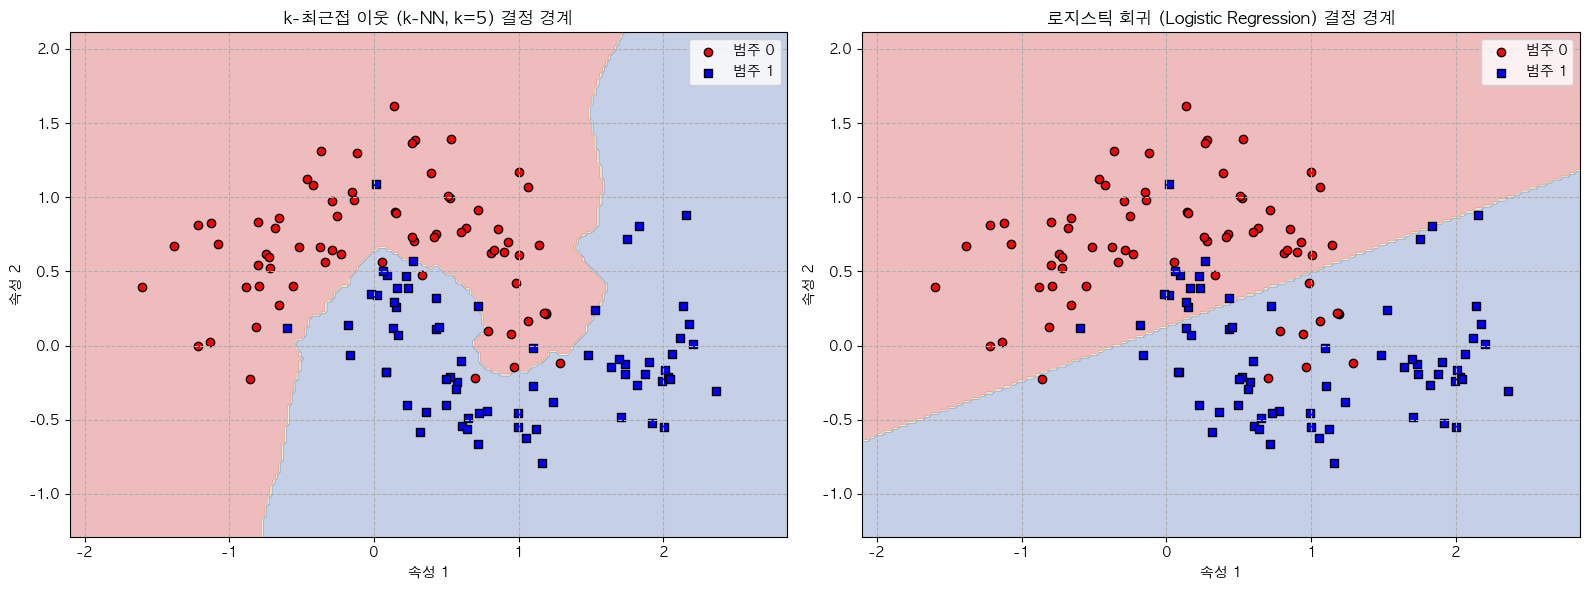

In [5]:
# [실습 3] 두 모델의 학습 및 결정 경계(Decision Boundary) 비교 시각화
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression

# 1. 모델 정의 및 학습
knn_model = KNeighborsClassifier(n_neighbors=5)
lr_model = LogisticRegression()

knn_model.fit(X_train, y_train)
lr_model.fit(X_train, y_train)

# 2. 결정 경계를 그리기 위한 격자 포인트 플로팅 함수 정의
def plot_decision_boundaries(X, y, model, title, ax):
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                         np.arange(y_min, y_max, 0.02))
    
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    
    ax.contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.RdYlBu)
    ax.scatter(X[y == 0, 0], X[y == 0, 1], color='red', marker='o', edgecolor='k', label='범주 0')
    ax.scatter(X[y == 1, 0], X[y == 1, 1], color='blue', marker='s', edgecolor='k', label='범주 1')
    ax.set_title(title)
    ax.set_xlabel("속성 1")
    ax.set_ylabel("속성 2")
    ax.legend()
    ax.grid(True, linestyle='--')

# 3. 서브플롯을 이용한 두 모델 대조 시각화
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

plot_decision_boundaries(X_train, y_train, knn_model, "k-최근접 이웃 (k-NN, k=5) 결정 경계", ax1)
plot_decision_boundaries(X_train, y_train, lr_model, "로지스틱 회귀 (Logistic Regression) 결정 경계", ax2)

plt.tight_layout()
plt.show()

=== [k-NN 성능 요약 데이터] ===
혼동 행렬(Confusion Matrix):
[[28  2]
 [ 1 29]]
정확도 (Accuracy) : 0.9500
정밀도 (Precision): 0.9355
재현율 (Recall)   : 0.9667

=== [로지스틱 회귀 성능 요약 데이터] ===
혼동 행렬(Confusion Matrix):
[[26  4]
 [ 3 27]]
정확도 (Accuracy) : 0.8833
정밀도 (Precision): 0.8710
재현율 (Recall)   : 0.9000



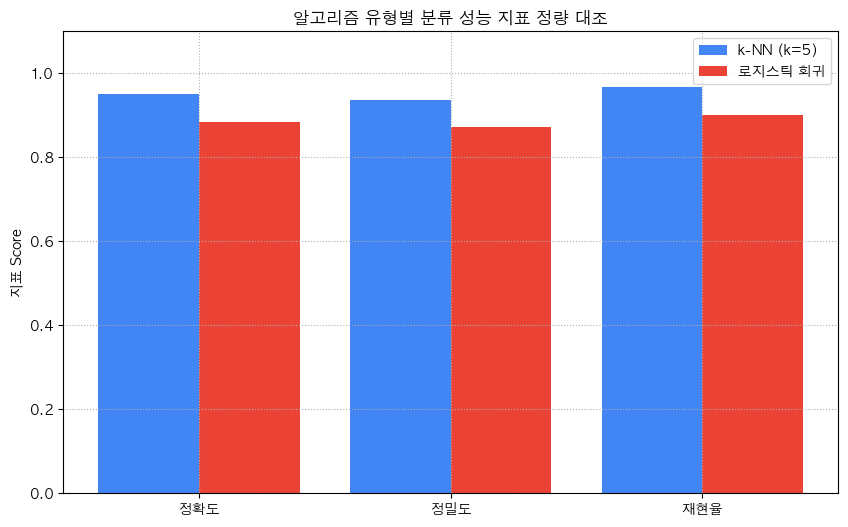

In [6]:
# [실습 4] 혼동 행렬(Confusion Matrix)과 분류 평가지표 연산 및 대조
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix

def evaluate_model_performance(model, X_test, y_test, model_name):
    y_pred = model.predict(X_test)
    
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    cm = confusion_matrix(y_test, y_pred)
    
    print(f"=== [{model_name} 성능 요약 데이터] ===")
    print(f"혼동 행렬(Confusion Matrix):\n{cm}")
    print(f"정확도 (Accuracy) : {acc:.4f}")
    print(f"정밀도 (Precision): {prec:.4f}")
    print(f"재현율 (Recall)   : {rec:.4f}\n")
    return [acc, prec, rec]

knn_scores = evaluate_model_performance(knn_model, X_test, y_test, "k-NN")
lr_scores = evaluate_model_performance(lr_model, X_test, y_test, "로지스틱 회귀")

# 두 모델 지표 성능 대조 막대그래프 출력
metrics_list = ['정확도', '정밀도', '재현율']
x_axis = np.arange(len(metrics_list))

plt.figure(figsize=(10, 6))
plt.bar(x_axis - 0.2, knn_scores, width=0.4, label='k-NN (k=5)', color='#4285F4')
plt.bar(x_axis + 0.2, lr_scores, width=0.4, label='로지스틱 회귀', color='#EA4335')

plt.xticks(x_axis, metrics_list)
plt.ylim(0, 1.1)
plt.title("알고리즘 유형별 분류 성능 지표 정량 대조")
plt.ylabel("지표 Score")
plt.legend()
plt.grid(True, linestyle=':')
plt.show()

## 4. 데이터 속성에 따른 알고리즘 특성 비교 정리

교재 내용 및 실습 결과를 바탕으로 두 모델의 속성 처리 방식을 비교 분석합니다.

| 비교 항목 | $k$-최근접 이웃 ($k$-NN) | 로지스틱 회귀 (Logistic Regression) |
| :--- | :--- | :--- |
| **모델의 형태** | 비모수적 모델 (수식적 구조 없음) | 모수적 모델 (선형 결합 및 시그모이드 수식 형태) |
| **결정 경계의 특성** | 데이터 분포의 세부 굴곡을 반영하는 복잡한 비선형 경계 형성 | 공간을 평면이나 직선으로 분할하는 직선형(선형) 경계 형성 |
| **속성 변화 영향도** | 모든 속성 간의 거리를 동등하게 취급하므로 특정 데이터 스케일에 민감함 | 각 데이터 속성에 부여되는 가중치(Weights) 크기를 통해 속성의 중요도를 파악 가능 |
| **적합한 데이터 유형** | 데이터 양이 아주 많지 않고 복잡한 패턴을 가진 정형 데이터 속성 | 선형적인 경계나 확률값 기반의 추정이 요구되는 정형 데이터 속성 |